# Final Project
## Emergency Department Analytics: From Statistics to Predictive Models

**Estimated time:** 1 hour

## Load dataset

In [11]:
import pandas as pd
df = pd.read_csv("https://statistical-analysis-and-data-modeling-in-healthcare-02a43a.gitlab.io/labs/final-project/ed_project_data.csv")
df.head()

,visit_id,age,triage_level,arrival_hr,ed_los_hours,num_tests_ordered,admitted
0,1,65,High,3,7.39,2,1
1,2,86,Medium,14,3.12,1,1
2,3,43,Medium,18,6.03,3,0
3,4,85,Low,0,2.74,2,1
4,5,41,High,15,9.45,1,0


## ✅ Task 1: Inspect dataset dimensions and column types

Write code that explicitly prints the number of rows and columns in the dataset, followed by code that displays the data type of every column. Your output should clearly show the dataset size and whether each variable is numeric or categorical.

In [12]:
# Basic Inspection
print('Rows, Columns:', df.shape)
print('\nColumn Data Types:')
print(df.dtypes)



Rows, Columns: (400, 7)

Column Data Types:
visit_id               int64
age                    int64
triage_level          object
arrival_hr             int64
ed_los_hours         float64
num_tests_ordered      int64
admitted               int64
dtype: object


## ✅ Task 2: Summarize ED length of stay

Write code that calculates the mean (average) and the median of the `ed_los_hours` column. Display both values clearly so that they can be compared.

In [13]:
# LOS Mean and Median

print('Mean LOS in ED:', df['ed_los_hours'].mean())
print('Median LOS in ED:', df['ed_los_hours'].median())


Mean LOS in ED: 5.0272
Median LOS in ED: 4.535


## ✅ Task 3: Compare LOS by admission status

Create a visualization that compares the distribution of emergency department length of stay (`ed_los_hours`) for patients who were admitted versus those who were not. A boxplot or similar comparison plot is expected.

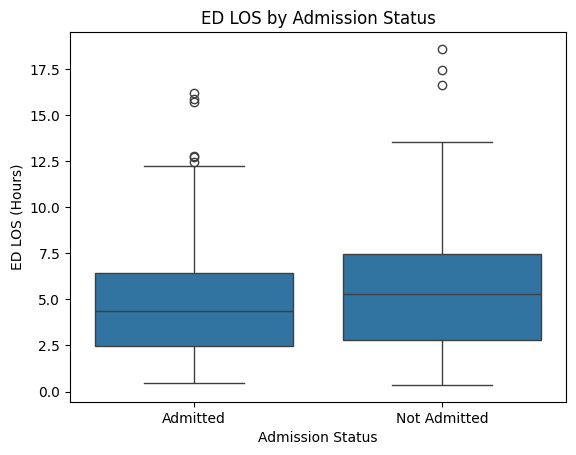

In [14]:
# LOS by Admission Status

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = 'admitted', y ='ed_los_hours', data=df)
plt.title('ED LOS by Admission Status')
plt.xlabel('Admission Status')
plt.xticks([0,1], ['Admitted', 'Not Admitted'])
plt.ylabel('ED LOS (Hours)')
plt.show()

## ✅ Task 4: Hypothesis test - Admission versus LOS

Perform an appropriate statistical hypothesis test to determine whether the mean emergency department length of stay differs between admitted and non-admitted patients. Report the test statistic and p-value.

In [15]:
# Hypothesis Test

from scipy import stats

# Separate into admitted vs. non-admitted groups for comparison:
los_admitted = df[df['admitted'] ==1]['ed_los_hours']
los_nonadmitted =df[df['admitted'] ==0]['ed_los_hours']

# t-test (independent)
t_statistic, p_value = stats.ttest_ind(los_admitted, los_nonadmitted)
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a significant difference in LOS between admitted and non-admitted patients.")
else:
    print("There is no significant difference.")

t-statistic: 2.070
p-value: 0.039
There is a significant difference in LOS between admitted and non-admitted patients.


## ✅ Task 5: ANOVA - LOS across triage levels

Use a one-way ANOVA to test whether the mean emergency department length of stay differs across the Low, Medium, and High triage categories. Output the F-statistic and p-value.

In [16]:
from scipy.stats import f_oneway

# Separate LOS by Triage Level

los_low = df[df['triage_level']=='Low']['ed_los_hours']
los_medium = df[df['triage_level']=='Medium']['ed_los_hours']
los_high = df[df['triage_level']=='High']['ed_los_hours']

# One-Way ANOVA

f_statistic, p_value = f_oneway(los_low, los_medium, los_high)
print('One-Way ANOVA:')
print(f"F-statistic: {f_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

One-Way ANOVA:
F-statistic: 0.121
p-value: 0.886


## ✅ Task 6: Logistic regression - Admission risk

Build and train a logistic regression model that predicts the binary `admitted` outcome using `age`, `ed_los_hours`, and `num_tests_ordered` as predictors. Use the variable name logistic_model to refer your model. Print the accuracy of the model using logistic_model.score(X,y).

In [17]:
# Admission Risk Using Logistic Regression

from sklearn.linear_model import LogisticRegression
X = df[['age', 'ed_los_hours', 'num_tests_ordered']]
y = df['admitted']

logistic_model = LogisticRegression()
logistic_model.fit(X,y)
print(f"Model Accuracy: {logistic_model.score(X, y):.3f}")

Model Accuracy: 0.695


## ✅ Task 7: Evaluate admission model (AUC)

Using the trained logistic regression model created earlier, generate predicted probabilities for admission and compute the ROC–AUC score. Display the numeric AUC value.

In [18]:
# Evaluate Admission Model (AUC)

from sklearn.metrics import roc_auc_score

y_pred_proba = logistic_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y, y_pred_proba)
print(f"ROC_AUC Score: {auc_score:.3f}")

ROC_AUC Score: 0.560


## ✅ Task 8: Decision tree model

Train a decision tree classification model that predicts the `admitted` outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name decision_tree_model to refer your model. Print the accuracy of the model using decision_tree_model.score(X,y).

In [19]:
# Training a Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X,y)
print(f"Model Accuracy: {decision_tree_model.score(X,y):.3f}")

Model Accuracy: 1.000


## ✅ Task 9: Random forest comparison

Train a random forest classifier classification model that predicts the admitted outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name random_forest_model to refer your model. Print the accuracy of the model using random_forest_model.score(X,y).

In [20]:
# Random Forest Comparison

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X,y)
print(f"Model Accuracy: {random_forest_model.score(X,y):.3f}")

Model Accuracy: 1.000


## ✅ Task 10: Operational interpretation

Based on the analysis, please see below for my operational interpretation.

Patients with longer emergency department length of stay and a higher number of diagnostic tests have an increased likelihood of hospital admission, suggesting these variables can be used for early risk stratification.
